# Train ResNeXt50 on OrganCMNIST

In [1]:

from pathlib import Path
import os
import shutil
import sys

ROOT = Path.cwd().parents[1].resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault(
    "PYTHON_JULIAPKG_PROJECT",
    str(Path.home() / "Documents" / "dev" / "MAGENetRunner" / "python_utils"),
)
os.environ.setdefault("PYTHON_JULIAPKG_OFFLINE", "yes")
julia_exe = shutil.which("julia")
if julia_exe is not None:
    os.environ.setdefault("PYTHON_JULIAPKG_EXE", julia_exe)


In [2]:

import torch

from python_utils.medmnist_resnet_baseline import (
    DatasetConfig,
    build_model,
    clean_checkpoints,
    evaluate_loader,
    load_checkpoint,
    plot_training_curves,
    prepare_experiment,
    print_metrics,
    select_best_checkpoint,
    train_model,
)


/home/camilo/Documents/dev/MAGENetRunner/.CondaPkg/env/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:

SEED = 123
TRAIN_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 512
EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
USE_CLASS_WEIGHTS = True
RESIZE_TO = 224

CONFIG = DatasetConfig(
    dataset_name="OrganCMNIST",
    train_file=str(ROOT / "datasets_pickle" / "OrganCMNIST_64_train.jld2"),
    val_file=str(ROOT / "datasets_pickle" / "OrganCMNIST_64_val.jld2"),
    test_file=str(ROOT / "datasets_pickle" / "OrganCMNIST_64_test.jld2"),
    num_classes=11,
    batch_size=TRAIN_BATCH_SIZE,
    val_batch_size=EVAL_BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    use_class_weights=USE_CLASS_WEIGHTS,
    seed=SEED,
    resize_to=RESIZE_TO,
    output_dir="ORGANCMNIST/NN_baselines",
    experiment_name="resnext50_OrganCMNIST",
    backbone_name="resnext50",
    nd=1,
    pretrained_weights="default",
)

CONFIG


DatasetConfig(dataset_name='OrganCMNIST', train_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganCMNIST_64_train.jld2', val_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganCMNIST_64_val.jld2', test_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganCMNIST_64_test.jld2', num_classes=11, batch_size=128, val_batch_size=512, epochs=30, lr=0.0001, weight_decay=0.0001, use_class_weights=True, seed=123, resize_to=224, output_dir='ORGANCMNIST/NN_baselines', experiment_name='resnext50_OrganCMNIST', backbone_name='resnext50', nd=1, pretrained_weights='default')

In [4]:

# Keep this False when evaluating existing checkpoints. Set True only for a fresh training run.
RUN_TRAINING = True
CONTEXT = prepare_experiment(CONFIG, clean_existing=RUN_TRAINING)
MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
OPTIMIZER = torch.optim.AdamW(
    MODEL.parameters(),
    lr=CONFIG.lr,
    weight_decay=CONFIG.weight_decay,
)


Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganCMNIST_64_train.jld2
Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganCMNIST_64_val.jld2
Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganCMNIST_64_test.jld2
TORCH DEVICE cuda
N CPUS 16
CWD : /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines
Metrics file: /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/cnn_metrics_resnet.csv
TRAIN DATASET SIZE : 12975
VAL DATASET SIZE : 2392
TEST DATASET SIZE : 8216
normalization mean: [0.4941606819629669, 0.4941606819629669, 0.4941606819629669] | std: [0.2734664976596832, 0.2734664976596832, 0.2734664976596832]
class weights: [1.027478575706482, 1.9055662155151367, 1.9824293851852417, 1.9659091234207153, 1.0841410160064697, 1.008158564567566, 0.3950252830982208, 1.1771910190582275, 1.1541540622711182, 1.0055800676345825, 0.7503469586372375]


In [5]:
import pandas as pd

if RUN_TRAINING:
    METRICS_DF = train_model(CONTEXT, MODEL, OPTIMIZER)
    METRICS_DF.tail()
else:
    print("Training skipped; reading existing metrics.")
    METRICS_DF = pd.read_csv(CONTEXT.metrics_file)
    METRICS_DF.tail()


Epoch [0/30], Train Loss: 2.4081, Train ACC: 0.0745, Train BACC: 0.0881
Epoch [0/30], Val Loss: 2.4233, Val ACC: 0.0832, Val BACC: 0.1032
Checkpoint saved at epoch 1 to /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/DLmodels_resnet/checkpoints/1.pth
Epoch [1/30], Train Loss: 0.8442, Train ACC: 0.7475, Train BACC: 0.7390
Epoch [1/30], Val Loss: 0.1482, Val ACC: 0.9670, Val BACC: 0.9495
Checkpoint saved at epoch 2 to /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/DLmodels_resnet/checkpoints/2.pth
Epoch [2/30], Train Loss: 0.1695, Train ACC: 0.9481, Train BACC: 0.9374
Epoch [2/30], Val Loss: 0.0898, Val ACC: 0.9791, Val BACC: 0.9707
Checkpoint saved at epoch 3 to /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/DLmodels_resnet/checkpoints/3.pth
Epoch [3/30], Train Loss: 0.0742, Train ACC: 0.9790, Train BACC: 0.9744
Epoch [3/30], Val Loss: 0.0691, Val ACC: 0.9858, Val BA

In [6]:

BEST_VAL_ACC_CKPT, METRICS_DF = select_best_checkpoint(CONTEXT, "val_accuracy")
BEST_VAL_ACC_MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
load_checkpoint(BEST_VAL_ACC_MODEL, BEST_VAL_ACC_CKPT, CONTEXT.device)
VAL_ACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_ACC_MODEL,
    CONTEXT.val_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
TEST_ACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_ACC_MODEL,
    CONTEXT.test_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
print_metrics("Best Val-ACC checkpoint | Validation", VAL_ACC_METRICS)
print_metrics("Best Val-ACC checkpoint | Test", TEST_ACC_METRICS)


Best val_accuracy: epoch 24
Checkpoint to read: /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/DLmodels_resnet/checkpoints/24.pth
Loaded checkpoint /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/DLmodels_resnet/checkpoints/24.pth
Best Val-ACC checkpoint | Validation Accuracy: 0.992
Best Val-ACC checkpoint | Validation Balanced Accuracy: 0.994
Best Val-ACC checkpoint | Validation AUC: 1.000
Best Val-ACC checkpoint | Test Accuracy: 0.941
Best Val-ACC checkpoint | Test Balanced Accuracy: 0.935
Best Val-ACC checkpoint | Test AUC: 0.996


In [7]:

BEST_VAL_BACC_CKPT, METRICS_DF = select_best_checkpoint(CONTEXT, "val_balanced_accuracy")
BEST_VAL_BACC_MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
load_checkpoint(BEST_VAL_BACC_MODEL, BEST_VAL_BACC_CKPT, CONTEXT.device)
VAL_BACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_BACC_MODEL,
    CONTEXT.val_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
TEST_BACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_BACC_MODEL,
    CONTEXT.test_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
print_metrics("Best Val-BACC checkpoint | Validation", VAL_BACC_METRICS)
print_metrics("Best Val-BACC checkpoint | Test", TEST_BACC_METRICS)


Best val_balanced_accuracy: epoch 29
Checkpoint to read: /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/DLmodels_resnet/checkpoints/29.pth
Loaded checkpoint /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/DLmodels_resnet/checkpoints/29.pth
Best Val-BACC checkpoint | Validation Accuracy: 0.992
Best Val-BACC checkpoint | Validation Balanced Accuracy: 0.994
Best Val-BACC checkpoint | Validation AUC: 1.000
Best Val-BACC checkpoint | Test Accuracy: 0.949
Best Val-BACC checkpoint | Test Balanced Accuracy: 0.944
Best Val-BACC checkpoint | Test AUC: 0.998


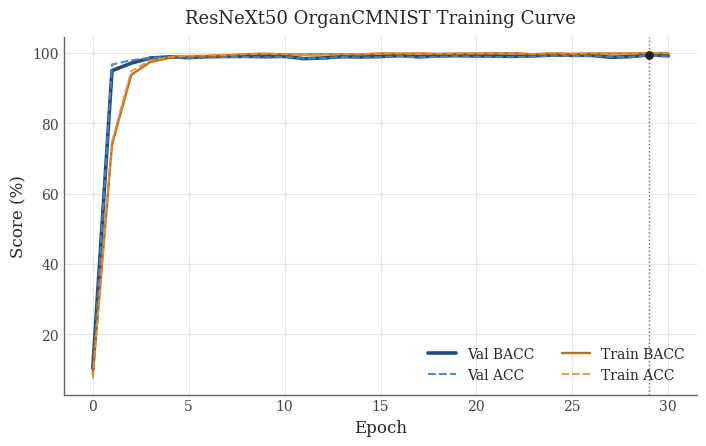

Saved plot to /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/training_curve_resnext50.png
Checkpoint cleanup skipped; saved checkpoints are preserved.


In [8]:

import pandas as pd
if "METRICS_DF" not in globals():
    METRICS_DF = pd.read_csv(CONTEXT.metrics_file)

PLOT_PATH = CONTEXT.folder / "training_curve_resnext50.png"
plot_training_curves(
    METRICS_DF,
    title="ResNeXt50 OrganCMNIST Training Curve",
    output_path=PLOT_PATH,
)
print("Checkpoint cleanup skipped; saved checkpoints are preserved.")


In [9]:
import json
import numpy as np
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score


def expected_calibration_error(labels, probabilities, n_bins=10):
    confidences = np.max(probabilities, axis=1)
    predictions = np.argmax(probabilities, axis=1)
    correct = (predictions == labels).astype(float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (confidences > lower) & (confidences <= upper)
        if not np.any(in_bin):
            continue
        ece += np.mean(in_bin) * abs(
            np.mean(correct[in_bin]) - np.mean(confidences[in_bin])
        )
    return float(ece)


def extended_metrics(model, loader, device, num_classes):
    _, labels, predictions, probabilities = evaluate_loader(
        model,
        loader,
        device,
        num_classes,
    )
    return {
        "bacc": float(balanced_accuracy_score(labels, predictions)),
        "macro_f1": float(f1_score(labels, predictions, average="macro")),
        "auroc": float(
            roc_auc_score(
                labels,
                probabilities,
                multi_class="ovr",
                average="macro",
            )
        ),
        "ece": expected_calibration_error(labels, probabilities),
    }


EXTENDED_VAL_BACC_METRICS = {
    "validation": extended_metrics(
        BEST_VAL_BACC_MODEL,
        CONTEXT.val_dataloader,
        CONTEXT.device,
        CONFIG.num_classes,
    ),
    "test": extended_metrics(
        BEST_VAL_BACC_MODEL,
        CONTEXT.test_dataloader,
        CONTEXT.device,
        CONFIG.num_classes,
    ),
}

print("Checkpoint:", BEST_VAL_BACC_CKPT)
print(json.dumps(EXTENDED_VAL_BACC_METRICS, indent=2))

EXTENDED_METRICS_PATH = CONTEXT.folder / "extended_metrics_best_val_bacc.json"
EXTENDED_METRICS_PATH.write_text(json.dumps(EXTENDED_VAL_BACC_METRICS, indent=2))
print("Saved extended metrics to", EXTENDED_METRICS_PATH)


Checkpoint: /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/DLmodels_resnet/checkpoints/29.pth
{
  "validation": {
    "bacc": 0.9944862322747853,
    "macro_f1": 0.9918335047896033,
    "auroc": 0.9999254578264698,
    "ece": 0.005077818676480502
  },
  "test": {
    "bacc": 0.944228991137133,
    "macro_f1": 0.944284369483178,
    "auroc": 0.9977494348748288,
    "ece": 0.03268916507005813
  }
}
Saved extended metrics to /home/camilo/Documents/dev/MAGENetRunner/ORGANCMNIST/NN_baselines/resnext50_OrganCMNIST/extended_metrics_best_val_bacc.json
